<a href="https://colab.research.google.com/github/Malaika-05/ML_mini-Tasks/blob/main/Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Task 2: Predict Future Stock Prices (Short-Term)

#Step 1: Install & Import Libraries

In [ ]:
pip install yfinance


In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Step 2: Load Stock Data

In [ ]:
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
print(df.head())

/tmp/ipykernel_7751/2501415353.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


#Step 3: Prepare Data

In [ ]:
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()

#Step 4: Select Features & Target

In [ ]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

#Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

#Step 6: Train Model (Linear Regression)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#Step 7: Predictions

In [ ]:
predictions = model.predict(X_test)

#Step 8: Plot Actual vs Predicted

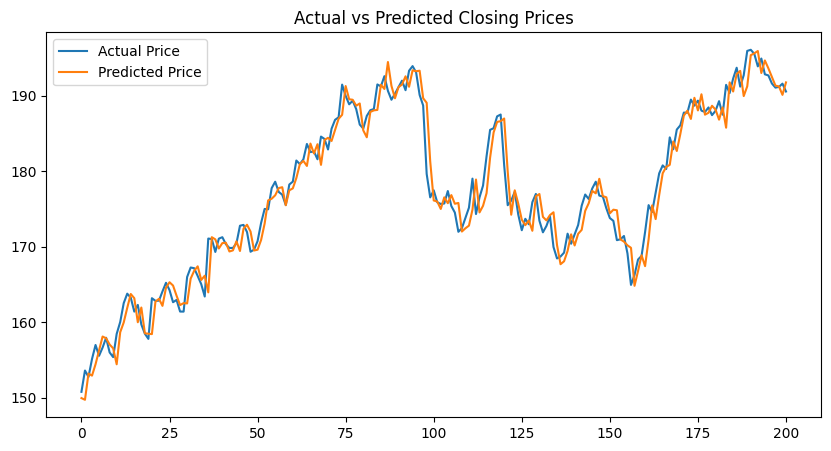

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Actual vs Predicted Closing Prices")
plt.legend()
plt.show()

#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 4.945957242801855
